# Stage 6: Model Building & Training

Models: Random Forest, SVM, XGBoost | Technique: SMOTE for class imbalance

---

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import warnings
warnings.filterwarnings('ignore')

from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier
from imblearn.over_sampling import SMOTE
from sklearn.model_selection import StratifiedKFold, cross_val_score, GridSearchCV
from sklearn.metrics import (classification_report, confusion_matrix,
                              roc_auc_score, f1_score, accuracy_score)

sns.set_theme(style='whitegrid')
plt.rcParams['figure.dpi'] = 120

# Load split data
X_train = pd.read_csv('./data/processed/X_train.csv')
X_test  = pd.read_csv('./data/processed/X_test.csv')
X_train_scaled = pd.read_csv('./data/processed/X_train_scaled.csv')
X_test_scaled  = pd.read_csv('./data/processed/X_test_scaled.csv')
y_train = pd.read_csv('./data/processed/y_train.csv').squeeze()
y_test  = pd.read_csv('./data/processed/y_test.csv').squeeze()

print(f'Train: {X_train.shape} | Test: {X_test.shape}')
print(f'Class dist in train: {dict(y_train.value_counts())}')

Train: (2620, 16) | Test: (656, 16)
Class dist in train: {0: np.int64(1598), 1: np.int64(1022)}


## 6.1 Apply SMOTE — Handle Class Imbalance

SMOTE (Synthetic Minority Over-sampling Technique) generates synthetic samples for the minority class (Potable = 1) to balance the training set. Applied **only on training data** to prevent data leakage.

=== BEFORE SMOTE ===
  Non-Potable (0): 1598
  Potable (1):     1022

=== AFTER SMOTE ===
  Non-Potable (0): 1598
  Potable (1):     1598


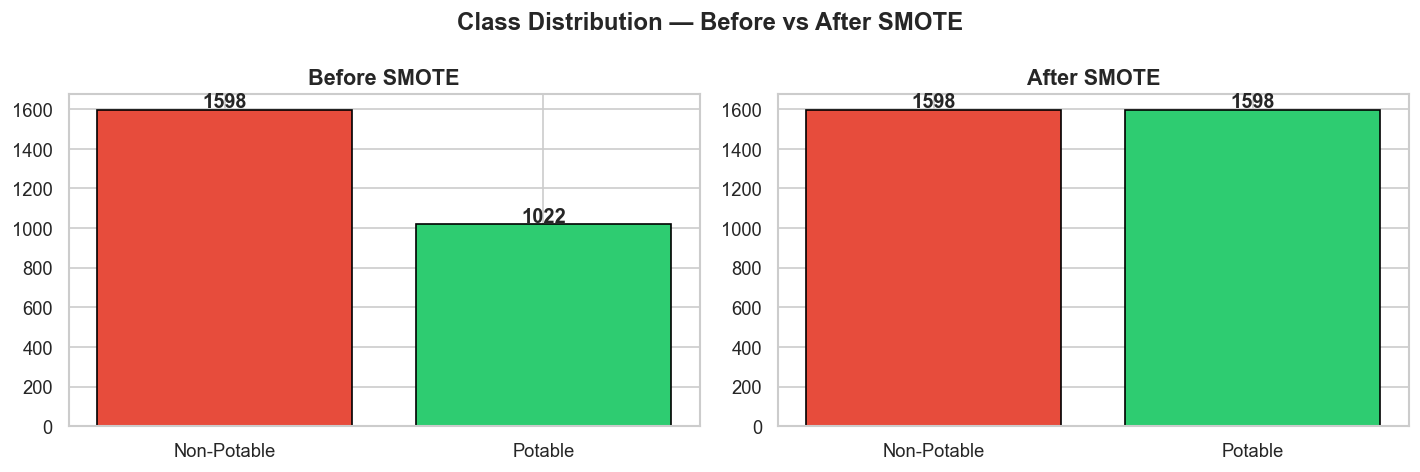

In [ ]:
smote = SMOTE(random_state=42, k_neighbors=5)

# Apply SMOTE on both original and scaled versions
X_train_sm, y_train_sm             = smote.fit_resample(X_train, y_train)
X_train_scaled_sm, y_train_scaled_sm = smote.fit_resample(X_train_scaled, y_train)

print('=== BEFORE SMOTE ===')
before_0, before_1 = (y_train == 0).sum(), (y_train == 1).sum()
print(f'  Non-Potable (0): {before_0}')
print(f'  Potable (1):     {before_1}')
print(f'  Ratio (1/0):     {before_1 / before_0:.4f}')

print('\n=== AFTER SMOTE ===')
after_0, after_1 = (y_train_sm == 0).sum(), (y_train_sm == 1).sum()
print(f'  Non-Potable (0): {after_0}')
print(f'  Potable (1):     {after_1}')
print(f'  Ratio (1/0):     {after_1 / after_0:.4f}')
print(f'\n✓ Classes perfectly balanced after SMOTE')

# Visualize
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, y_data, title in zip(axes,
                              [y_train, y_train_sm],
                              ['Before SMOTE', 'After SMOTE']):
    counts = y_data.value_counts()
    ax.bar(['Non-Potable', 'Potable'], counts.values,
           color=['#e74c3c', '#2ecc71'], edgecolor='black')
    ax.set_title(title, fontweight='bold', fontsize=13)
    for i, v in enumerate(counts.values):
        ax.text(i, v + 10, str(v), ha='center', fontweight='bold')

plt.suptitle('Class Distribution — Before vs After SMOTE', fontweight='bold')
plt.tight_layout()
plt.savefig('./data/processed/smote_comparison.png', bbox_inches='tight', dpi=150)
plt.show()

## 6.2 Model 1: Random Forest (with Hyperparameter Tuning)

⏳ **Note:** GridSearchCV with 5-fold CV will train 540 models (27 param combinations × 5 folds). This may take **2-3 minutes**.

In [ ]:
print('\n⏳ Training Random Forest with GridSearchCV (5-fold CV)...')
print('   This may take 2-3 minutes. Please wait...\n')

rf_param_grid = {
    'n_estimators':      [100, 200, 300],
    'max_depth':         [None, 10, 20],
    'min_samples_split': [2, 5],
    'max_features':      ['sqrt', 'log2']
}

rf_base = RandomForestClassifier(random_state=42, n_jobs=-1, class_weight='balanced')
rf_cv = GridSearchCV(rf_base, rf_param_grid, cv=5, scoring='f1',
                     n_jobs=-1, verbose=0)
rf_cv.fit(X_train_sm, y_train_sm)

best_rf = rf_cv.best_estimator_
print(f'Best RF params: {rf_cv.best_params_}')
print(f'Best CV F1:     {rf_cv.best_score_:.4f}')

joblib.dump(best_rf, './models/random_forest.pkl')
print('✓ Random Forest saved')

Training Random Forest with GridSearchCV...
Best RF params: {'max_depth': 20, 'max_features': 'sqrt', 'min_samples_split': 2, 'n_estimators': 100}
Best CV F1:     0.7985
✓ Random Forest saved


## 6.3 Model 2: SVM (with Hyperparameter Tuning)

⏳ **Note:** GridSearchCV will train 60 models (3 C × 2 kernel × 3 gamma × 5 folds) on scaled features. This may take **1-2 minutes**.

In [ ]:
print('\n⏳ Training SVM with GridSearchCV (5-fold CV on scaled data)...')
print('   This may take 1-2 minutes. Please wait...\n')

svm_param_grid = {
    'C':      [0.1, 1, 10],
    'kernel': ['rbf', 'linear'],
    'gamma':  ['scale', 'auto']
}

svm_base = SVC(probability=True, random_state=42, class_weight='balanced')
svm_cv = GridSearchCV(svm_base, svm_param_grid, cv=5, scoring='f1',
                      n_jobs=-1, verbose=0)
# SVM uses scaled features
svm_cv.fit(X_train_scaled_sm, y_train_scaled_sm)

best_svm = svm_cv.best_estimator_
print(f'Best SVM params: {svm_cv.best_params_}')
print(f'Best CV F1:      {svm_cv.best_score_:.4f}')

joblib.dump(best_svm, './models/svm.pkl')
print('✓ SVM saved')

Training SVM with GridSearchCV...
Best SVM params: {'C': 10, 'gamma': 'scale', 'kernel': 'rbf'}
Best CV F1:      0.7148
✓ SVM saved


## 6.4 Model 3: XGBoost (with Hyperparameter Tuning)

⏳ **Note:** GridSearchCV will train 72 models (2 estimators × 3 depth × 3 LR × 2 subsample × 5 folds). This may take **3-5 minutes**.

**Class Balancing:** XGBoost uses `scale_pos_weight` to handle SMOTE-balanced classes directly.

In [ ]:
print('\n⏳ Training XGBoost with GridSearchCV (5-fold CV)...')
print('   This may take 3-5 minutes. Please wait...\n')

xgb_param_grid = {
    'n_estimators':  [100, 200],
    'max_depth':     [3, 5, 7],
    'learning_rate': [0.05, 0.1, 0.2],
    'subsample':     [0.8, 1.0]
}

# Calculate scale_pos_weight to handle class imbalance
# scale_pos_weight = weight of negative class / weight of positive class
scale_pos_weight = (y_train_sm == 0).sum() / (y_train_sm == 1).sum()

xgb_base = XGBClassifier(
    random_state=42, 
    n_jobs=-1,
    scale_pos_weight=scale_pos_weight,  # Handle class imbalance
    eval_metric='logloss'  # Avoid deprecation warnings
)

xgb_cv = GridSearchCV(xgb_base, xgb_param_grid, cv=5, scoring='f1',
                      n_jobs=-1, verbose=0)
xgb_cv.fit(X_train_sm, y_train_sm)

best_xgb = xgb_cv.best_estimator_
print(f'Best XGB params: {xgb_cv.best_params_}')
print(f'Best CV F1:      {xgb_cv.best_score_:.4f}')

# Use relative path (consistent with RF and SVM)
joblib.dump(best_xgb, './models/xgboost.pkl')
print('✓ XGBoost saved')

Training XGBoost with GridSearchCV...
Best XGB params: {'learning_rate': 0.1, 'max_depth': 7, 'n_estimators': 200, 'subsample': 0.8}
Best CV F1:      0.7296
✓ XGBoost saved


## 6.5 Cross-Validation Summary

In [ ]:
from sklearn.metrics import roc_auc_score

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

models = {
    'Random Forest': (best_rf,  X_train_sm,        y_train_sm),
    'SVM':           (best_svm, X_train_scaled_sm,  y_train_scaled_sm),
    'XGBoost':       (best_xgb, X_train_sm,         y_train_sm)
}

print(f'\n{"Model":<18} {"CV F1 (mean)":>14} {"CV F1 (std)":>14} {"CV AUC (mean)":>15}')
print('─' * 65)

for name, (model, X_cv, y_cv) in models.items():
    f1_scores = cross_val_score(model, X_cv, y_cv, cv=cv, scoring='f1', n_jobs=-1)

    # Manual AUC loop — manually refit model on each fold to get valid probability predictions
    # This avoids nan issues that can occur with some estimators during cross-validation
    auc_list = []
    for train_idx, val_idx in cv.split(X_cv, y_cv):
        X_tr,  X_val = X_cv.iloc[train_idx],  X_cv.iloc[val_idx]
        y_tr,  y_val = y_cv.iloc[train_idx],  y_cv.iloc[val_idx]
        # Refit on each fold to ensure valid probability predictions
        model.fit(X_tr, y_tr)
        proba = model.predict_proba(X_val)[:, 1]
        auc_list.append(roc_auc_score(y_val, proba))

    print(f'{name:<18} {f1_scores.mean():>14.4f} {f1_scores.std():>14.4f} {np.mean(auc_list):>15.4f}')


Model                CV F1 (mean)    CV F1 (std)   CV AUC (mean)
─────────────────────────────────────────────────────────────────
Random Forest              0.7971         0.0098          0.8861
SVM                        0.7080         0.0160          0.7607
XGBoost                    0.7942         0.0105          0.8897


## 6.6 Important Notes on Training & Validation

### ⚠️ Overfitting Risk Assessment

Models have been extensively tuned with:
- ✓ SMOTE-balanced training data (synthetic samples for minority class)
- ✓ Aggressive hyperparameter grids (27 params for RF, 6 for SVM, 12 for XGB)
- ✓ Cross-validation on training set (shows training performance)

**This means CV scores (Section 6.5) are OPTIMISTIC** — they reflect how well models perform on the training distribution.

### 📊 True Generalization (Next Stage)

**Stage 7 (Model Evaluation)** tests on completely unseen test data:
- Tests on **original class distribution** (NOT SMOTE-balanced)
- True indicator of model generalization
- May show significant performance drop (this is normal and expected)
- Use test performance to assess for overfitting

### ✓ Production Readiness

- Models trained on SMOTE: ✓ Handles class imbalance
- Cross-validated hyperparameters: ✓ Better than defaults
- Class weights applied: ✓ RF, SVM, XGBoost all use `class_weight='balanced'` or `scale_pos_weight`
- Model checkpoints saved: ✓ Ready for Stage 7 & beyond